# SEA: Segment, Embed, and Align
## Complete End-to-End Subtitle Alignment Walkthrough — Minute-Level Detail

**Paper:** *Segment, Embed, and Align: A Universal Recipe for Aligning Subtitles to Signing*  
Zifan Jiang, Youngjoon Jang, Liliane Momeni, Gül Varol, Sarah Ebling, Andrew Zisserman (2025)  
[arXiv:2512.08094](https://arxiv.org/abs/2512.08094)

---

### The Core Problem This Notebook Solves

When a sign language video is produced, its subtitles are typically generated from the **spoken audio track** — either by a human interpreter or automatic speech recognition. This means every subtitle timestamp reflects when the word was *spoken*, not when it was *signed*.

Signing lags behind speech by a variable delay (often 2–5 seconds) due to interpretation lag, the slower articulation rate of sign language, and grammatical reordering. The result is subtitles that appear **seconds before or after** the signing they describe.

**SEA corrects this** by treating alignment as an optimisation problem: given a sequence of subtitle cues $\{c_1, c_2, \ldots, c_M\}$ and a sequence of sign-language segments $\{s_1, s_2, \ldots, s_N\}$, find the mapping that minimises total temporal mismatch.

---

### Key Terminology

| Term | Precise Definition |
|------|-------------------|
| **Alignment** | The operation of replacing a subtitle cue's `(start, end)` timestamps with new values that correspond to when that subtitle's content is actually being signed. The *text* is never modified. |
| **Gloss / Gloss Label** | A written token that represents a single sign gesture, transcribed using a spoken-language word or phrase that approximates the sign's meaning. Example: `สวัสดี` (hello), `(ผายมือ)` (open-hand wave). Each gloss is time-stamped at sub-second precision. |
| **ELAN / EAF** | ELAN (EUDICO Linguistic Annotator) is the industry-standard tool for multimodal corpus annotation. EAF (ELAN Annotation Format) files are XML documents storing multiple overlapping time-aligned annotation layers (*tiers*) over the same video. |
| **Cue** | One subtitle segment: a `(start, end, text)` triple representing a sentence-length unit of spoken/signed content. |
| **Sign segment** | A single sign gesture with a precise temporal boundary — the smallest unit used as an anchor in the DP alignment. |
| **DP (Dynamic Programming)** | A class of algorithms that solve optimisation problems by breaking them into overlapping sub-problems and caching intermediate results. Here, DP finds the globally optimal alignment in O(M × N) time (with windowing). |

---

### What This Notebook Covers

| Section | Content | Key SEA File |
|---------|---------|-------------|
| 1 | Environment & path setup | — |
| 2 | Loading and inspecting the ELAN annotation file | `utils.py` |
| 3 | Extracting subtitle cues and sign-segment anchors | `utils.py` |
| 4 | Numba JIT warmup | `align_dp.py` |
| 5 | Running the DP alignment algorithm | `align_dp.py` |
| 6 | Writing the output EAF and WebVTT files | `utils.py` |
| 7 | Quantitative evaluation + metric visualisation | `misc/evaluate_sub_alignment.py` |
| 8 | Timeline visualisation | matplotlib |

> **Prerequisites:** Run `uv sync` from the repository root and activate `.venv` before starting the Jupyter kernel.

---
## Section 1 — Environment & Path Setup

### 1.1 — How Python Finds Modules: `sys.path` in Depth

When you write `import align_dp`, Python searches **in order** through every directory listed in `sys.path`. If none of them contains a file called `align_dp.py` (or a package directory `align_dp/`), you get an `ImportError`.

By default, a Jupyter kernel launched from `notebooks/` has a `sys.path` that includes:
- The kernel's site-packages (our `.venv/Lib/site-packages/`)
- The current working directory (`notebooks/`)

It does **not** include `SEA/` or `SEA/misc/`. We must add them manually.

**Why `SEA/misc/` too?**  
`align_dp.py` contains the line `from align_dp_visualization import visualize_similarity_heatmap` at module import time. This bare import (no package prefix) only resolves if `SEA/` is on `sys.path`. Similarly, `misc/evaluate_sub_alignment.py` uses bare imports from the same directory. Adding `SEA/misc/` lets us do `from evaluate_sub_alignment import eval_subtitle_alignment` directly.

**Why `sys.path.insert(0, ...)` and not `.append(...)`?**  
Using index 0 makes our local `SEA/` modules take priority over any identically-named packages that might be installed in site-packages. This prevents shadowing bugs.

**`Path.cwd().parent` vs `__file__`**  
In a `.py` script, `__file__` is reliable. In a Jupyter notebook, `__file__` is undefined. `Path.cwd()` returns the directory from which the Jupyter kernel was launched — which is `notebooks/` when started via `cd notebooks && jupyter notebook`. Taking `.parent` gives us the repository root.

In [1]:
import sys
import os
from pathlib import Path

# The Jupyter kernel is launched from notebooks/, so cwd() is notebooks/.
# .parent steps up one level to the repository root.
REPO_ROOT = Path(os.getcwd()).parent

# SEA/ contains all core algorithm files (align_dp.py, utils.py, etc.).
SEA_DIR  = REPO_ROOT / "SEA"

# SEA/misc/ contains evaluate_sub_alignment.py.
MISC_DIR = SEA_DIR / "misc"

# data/example_alignment/ holds the Thai Sign Language demo dataset.
DATA_DIR = REPO_ROOT / "data" / "example_alignment"

# assets/ is where we save publication-quality figures.
ASSETS_DIR = REPO_ROOT / "assets"
ASSETS_DIR.mkdir(exist_ok=True)

# Add to front of sys.path so local modules shadow any installed packages.
for p in [str(SEA_DIR), str(MISC_DIR)]:
    if p not in sys.path:
        sys.path.insert(0, p)

# Sanity checks — fail loudly if paths are wrong.
assert REPO_ROOT.exists(),  f"Repo root not found: {REPO_ROOT}"
assert SEA_DIR.exists(),    f"SEA source dir not found: {SEA_DIR}"
assert DATA_DIR.exists(),   f"Data dir not found: {DATA_DIR}"

print(f"Repository root  : {REPO_ROOT}")
print(f"SEA source dir   : {SEA_DIR}")
print(f"Example data dir : {DATA_DIR}")
print(f"Assets output dir: {ASSETS_DIR}")
print(f"\nsys.path (first 3 entries):")
for p in sys.path[:3]:
    print(f"  {p}")

Repository root  : c:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub
SEA source dir   : c:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\SEA
Example data dir : c:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\data\example_alignment
Assets output dir: c:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\assets

sys.path (first 3 entries):
  c:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\SEA\misc
  c:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\SEA
  C:\Users\USER\AppData\Roaming\uv\python\cpython-3.12.12-windows-x86_64-none\python312.zip


### 1.2 — CUDA Device Detection: What Happens Under the Hood

**Why we check for a GPU at all:**  
The SEA pipeline has two compute-intensive phases:
1. **DP alignment** (`align_dp.py`) — runs entirely on CPU via numba-compiled C code.
   No GPU needed or used here, regardless of what’s available.
2. **Embedding** (`align_similarity.py`) — if `similarity_measure=sign_clip_embedding`
   or `text_embedding`, PyTorch models are loaded and run inference.
   This benefits massively from a CUDA GPU.

This notebook runs the DP alignment stage only (no embeddings in Section 5). The GPU
is detected and the `DEVICE` variable is set here so that any embedding extension
cells (see Section 9) can reference it without repeating the detection logic.

**What `torch.cuda.is_available()` actually checks:**  
1. Was PyTorch compiled with CUDA support?
   (Our `torch==2.7.0+cu128` wheel from the PyTorch CUDA 12.8 index has full
    native support for Blackwell GPUs — RTX 50xx / sm_120.)
2. Is a CUDA-capable NVIDIA GPU present in the system?
3. Is a compatible CUDA driver installed (≥ the CUDA toolkit version PyTorch was
   compiled with — CUDA 12.8 requires driver ≥ 525.60.13 on Linux / ≥ 527.41 on Windows)?

All three must be true. If your GPU is detected but `cuda: False`, the driver
version is almost always the culprit.

**`torch.device` vs a plain string:**  
`torch.device('cuda')` is a typed object. Passing it to `model.to(DEVICE)` or
`tensor.to(DEVICE)` is identical to passing the string `'cuda'`, but the typed
object gives better error messages and is preferred by type checkers.

In [2]:
import torch

# Standard device-agnostic setup used throughout PyTorch codebases.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch version  : {torch.__version__}")
print(f"Active device    : {DEVICE}")

if DEVICE.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"GPU model        : {props.name}")
    print(f"VRAM total       : {props.total_memory / 1e9:.1f} GB")
    print(f"CUDA capability  : {props.major}.{props.minor}")
    print(f"Multiprocessors  : {props.multi_processor_count}")
else:
    print("No CUDA GPU detected.")
    print("DP alignment runs entirely on CPU via numba — this is fully supported and normal.")

PyTorch version  : 2.7.0+cu128
Active device    : cuda
GPU model        : NVIDIA GeForce RTX 5060 Ti
VRAM total       : 17.1 GB
CUDA capability  : 12.0
Multiprocessors  : 36


---
## Section 2 — Load and Inspect the ELAN Annotation File

### 2.1 — The ELAN XML Schema and the Thai Filename Challenge

**ELAN file structure (abridged):**
```xml
<ANNOTATION_DOCUMENT>
  <HEADER>
    <MEDIA_DESCRIPTOR MEDIA_URL="04.mp4" MIME_TYPE="video/mp4"/>
  </HEADER>

  <!-- TIME_ORDER: the global clock. Every annotation references two TIME_SLOTs. -->
  <TIME_ORDER>
    <TIME_SLOT TIME_SLOT_ID="ts1" TIME_VALUE="40"/>   <!-- 40 ms -->
    <TIME_SLOT TIME_SLOT_ID="ts2" TIME_VALUE="31890"/> <!-- 31.89 s -->
    ...
  </TIME_ORDER>

  <!-- Each TIER is one annotation layer (e.g. CC, Gloss Labeling, ...). -->
  <TIER TIER_ID="CC" LINGUISTIC_TYPE_REF="imported-sub">
    <ANNOTATION>
      <ALIGNABLE_ANNOTATION ANNOTATION_ID="a1"
                            TIME_SLOT_REF1="ts1"   <!-- references TIME_ORDER -->
                            TIME_SLOT_REF2="ts2">
        <ANNOTATION_VALUE>[เสียงดนตรี]</ANNOTATION_VALUE>
      </ALIGNABLE_ANNOTATION>
    </ANNOTATION>
  </TIER>
  ...
</ANNOTATION_DOCUMENT>
```

**The two-level indirection** — `TIME_SLOT_REF1="ts1"` → `TIME_SLOT TIME_SLOT_ID="ts1" TIME_VALUE="40"` — means that multiple annotations can reference the same time point. Changing one `TIME_VALUE` automatically adjusts every annotation that references it. This is why `write_updated_eaf()` must add *new* `TIME_SLOT` entries rather than modifying existing ones when it appends the `SUBTITLE_SHIFTED` tier.

**Thai Unicode filenames:**  
The file is named `การเปรียบเทียบและเรียงลำดับ (11.07 นาที).eaf`. On Windows the filesystem uses UTF-16 internally, so Python's `Path` API handles this correctly. The risk is with string concatenation — `"data/" + filename` in a cp1252 terminal can corrupt the string. We use `Path.glob("*.eaf")` which resolves the glob at the OS level without ever constructing the filename as a string.

**`pympi.Elan` under the hood:**  
`pympi` parses the XML with Python's `xml.etree.ElementTree`, builds an internal dictionary of `tier_name → list of (start_ms, end_ms, value)` tuples, and resolves the two-level TIME_SLOT indirection automatically. All timestamps it returns are in **milliseconds** as integers.

In [3]:
import pympi

# Glob discovers all .eaf files without constructing the Thai filename manually.
# We exclude *_updated.eaf — those are outputs from previous notebook runs.
all_eaf_files = list(DATA_DIR.glob("*.eaf"))
original_eaf  = next((f for f in all_eaf_files if "_updated" not in f.name), None)

if original_eaf is None:
    raise FileNotFoundError(f"No original .eaf file found in {DATA_DIR}")

print(f"Found EAF file : {original_eaf.name}")
print(f"File size      : {original_eaf.stat().st_size / 1024:.1f} KB")

# pympi.Elan() parses the XML, resolves all TIME_SLOT references,
# and populates internal dictionaries for fast tier access.
elan = pympi.Elan.Eaf(str(original_eaf))

print("\nTier inventory:")
print(f"  {'Tier name':<20} {'Annotations':>12}")
print(f"  {'─' * 20} {'─' * 12}")
for tier_name in elan.get_tier_names():
    n = len(elan.get_annotation_data_for_tier(tier_name))
    print(f"  {tier_name:<20} {n:>12}")

Found EAF file : การเปรียบเทียบและเรียงลำดับ (11.07 นาที).eaf
File size      : 493.5 KB

Tier inventory:
  Tier name             Annotations
  ──────────────────── ────────────
  CC                            172
  CC_Aligned                    119
  Gloss                         119
  Gloss Labeling                852


### 2.2 — The Four Tiers in Detail: Semantic Roles and Granularity

`pympi.Elan.get_annotation_data_for_tier(tier_name)` returns a list of `(start_ms: int, end_ms: int, value: str)` tuples. The order is not guaranteed to be chronological — ELAN stores annotations in annotation-ID order, which may differ from time order if annotations were created interactively. We therefore sort by `start_ms` in our extraction function.

**Tier roles and SEA pipeline mapping:**

```
Tier: CC (Closed Captions)
  → Raw Thai text transcription from the audio track.
  → ~1 sentence per annotation. Contains music cues like "[เสียงดนตรี]".
  → Not used directly in this notebook.

Tier: CC_Aligned
  → A refined version of CC with improved timestamps.
  → These are the INPUT SUBTITLE CUES for the DP aligner.
  → In the full SEA pipeline this tier is replaced by a .vtt file parsed by utils.get_subtitle_cues().

Tier: Gloss
  → One annotation per sentence, containing the full TSL gloss sequence for that sentence.
  → Example: "สวัสดี (ผายมือ) เด็ก เรียน (ผายมือ)" — 5 sign units in one annotation.
  → Sentence-level granularity. Too coarse for DP alignment anchors.

Tier: Gloss Labeling
  → ONE ANNOTATION PER SIGN GESTURE.
  → This is the SIGN-SEGMENT SOURCE for the DP aligner.
  → In the full SEA pipeline, segmentation.py generates the equivalent 'SIGN' tier automatically
     from MediaPipe poses. This tier is what utils.get_sign_segments_from_eaf() reads.
  → Our example has it pre-annotated by a human expert.
```

The **ratio of CC_Aligned to Gloss Labeling** tells us how many sign units the aligner must search through per subtitle cue — this determines the DP search complexity.

In [4]:
import pandas as pd

pd.set_option("display.max_colwidth", 55)
pd.set_option("display.width", 130)

for tier_name in elan.get_tier_names():
    all_anns = elan.get_annotation_data_for_tier(tier_name)
    sample   = sorted(all_anns, key=lambda x: x[0])[:5]  # sort by start_ms, show first 5
    rows = [
        {
            "start_s":    round(s / 1000, 3),
            "end_s":      round(e / 1000, 3),
            "duration_s": round((e - s) / 1000, 3),
            "value":      v[:52] if v else "(empty)",
        }
        for s, e, v in sample
    ]
    total_n = len(all_anns)
    time_span = (sorted(all_anns, key=lambda x: x[0])[0][0] / 1000,
                 sorted(all_anns, key=lambda x: x[1])[-1][1] / 1000)
    print(f"\n{'═'*80}")
    print(f"TIER: '{tier_name}'  |  {total_n} annotations  |  "
          f"span: {time_span[0]:.1f}s → {time_span[1]:.1f}s")
    print(f"{'─'*80}")
    print(pd.DataFrame(rows).to_string(index=False))


════════════════════════════════════════════════════════════════════════════════
TIER: 'CC'  |  172 annotations  |  span: 0.0s → 663.6s
────────────────────────────────────────────────────────────────────────────────
 start_s  end_s  duration_s                                   value
    0.04  31.89       31.85                            [เสียงดนตรี]
   34.03  36.21        2.18 (คุณครูจิรชพรรณ) สวัสดีค่ะนักเรียนทุกคน
   36.71  39.80        3.09   คลิปต่อไปนะคะ เราก็จะมาเรียนรู้กันค่ะ
   39.83  41.29        1.46                 เกี่ยวกับการเปรียบเทียบ
   41.29  43.42        2.13                และก็เรียงลำดับจำนวนนะคะ

════════════════════════════════════════════════════════════════════════════════
TIER: 'CC_Aligned'  |  119 annotations  |  span: 33.6s → 646.6s
────────────────────────────────────────────────────────────────────────────────
 start_s  end_s  duration_s                                                value
  33.557 37.330       3.773              เราไปดูหลักและวิธีการเปรี

---
## Section 3 — Extract Subtitle Cues and Sign Segments

### 3.1 — The SEA Internal Data Format: `{start, end, mid, text}` Dicts

The entire SEA codebase represents both subtitle cues and sign segments as **Python dicts** with four keys:

```python
{
    'start': float,  # segment start time in seconds (NOT milliseconds)
    'end':   float,  # segment end time in seconds
    'mid':   float,  # temporal midpoint = (start + end) / 2
    'text':  str,    # annotation text (gloss token or subtitle sentence)
}
```

**Why the `mid` field?**  
The DP aligner uses `mid` to determine the **candidate window** for each subtitle cue (see `align_dp.py:dp_align_subtitles_to_signs`). For cue $i$, it searches sign segments whose `mid` falls within ±`window_size/2` of the cue's `mid`. This windowing reduces the O(M × N²) naive search to O(M × window_size²).

**The SIGN tier mismatch — why we can't use `utils.get_sign_segments_from_eaf()`:**  
In `SEA/utils.py` at line 191:
```python
for tier in root.findall("TIER"):
    if tier.get("TIER_ID") == "SIGN":  # ← hardcoded!
        sign_tier = tier
        break
```
This function was designed for ELAN files produced by `segmentation.py`, which always names its output tier `SIGN`. Our example file has no `SIGN` tier — it has `Gloss Labeling`. Calling `get_sign_segments_from_eaf()` on our file would return an empty list `[]`, and the DP aligner would silently produce no output.

Our `elan_tier_to_cues()` helper is a generalised replacement that reads **any named tier**.

**Unit conversion:**  
pympi returns milliseconds (e.g. `31890`). SEA works in seconds (e.g. `31.89`). The conversion is `/1000.0`. We use `float` division, not `//`, to preserve sub-millisecond precision from the XML.

In [5]:
def elan_tier_to_cues(elan_obj: pympi.Elan, tier_name: str) -> list:
    """
    Convert an ELAN tier to the list-of-dicts format used throughout SEA.

    This is a generalised alternative to utils.get_sign_segments_from_eaf(),
    which is hardcoded to look for a 'SIGN' tier only (utils.py:191).

    Args:
        elan_obj:   A loaded pympi.Elan instance.
        tier_name:  The TIER_ID string to extract from the EAF.

    Returns:
        List of {'start': float, 'end': float, 'mid': float, 'text': str} dicts,
        sorted ascending by start time.
    """
    raw = elan_obj.get_annotation_data_for_tier(tier_name)  # [(start_ms, end_ms, value), ...]
    cues = []
    for start_ms, end_ms, text in raw:
        start = start_ms / 1000.0   # milliseconds → seconds
        end   = end_ms   / 1000.0
        cues.append({
            'start': start,
            'end':   end,
            'mid':   (start + end) / 2.0,  # used for DP candidate window centering
            'text':  text if text else "",
        })
    # Sort by start time — ELAN stores in annotation-ID order, not time order.
    cues.sort(key=lambda c: c['start'])
    return cues


# ── Extract the two input lists for the DP aligner ──────────────────────────

# Subtitle cues: sentence-level Thai captions (input to DP alignment).
# These are the timestamps we want to CORRECT.
cues = elan_tier_to_cues(elan, "CC_Aligned")

# Sign-segment anchors: sub-sentence gloss labels (temporal references).
# These are the timestamps we want to ALIGN TO.
sign_segments = elan_tier_to_cues(elan, "Gloss Labeling")

print(f"Subtitle cues (CC_Aligned)   : {len(cues):>5} entries")
print(f"Sign segments (Gloss Labeling): {len(sign_segments):>5} entries")
print(f"\nCue time span  : {cues[0]['start']:.3f}s → {cues[-1]['end']:.3f}s")
print(f"Sign time span : {sign_segments[0]['start']:.3f}s → {sign_segments[-1]['end']:.3f}s")
print(f"\nAvg signs per cue  : {len(sign_segments)/len(cues):.1f}")
print(f"Avg cue duration   : {sum(c['end']-c['start'] for c in cues)/len(cues):.2f}s")
print(f"Avg sign duration  : {sum(s['end']-s['start'] for s in sign_segments)/len(sign_segments):.2f}s")

Subtitle cues (CC_Aligned)   :   119 entries
Sign segments (Gloss Labeling):   852 entries

Cue time span  : 33.557s → 646.583s
Sign time span : 33.557s → 646.583s

Avg signs per cue  : 7.2
Avg cue duration   : 4.71s
Avg sign duration  : 0.48s


### 3.2 — Data Validation: Why Each Check Matters

Before passing data to the numba JIT function we validate aggressively. Here is why each check is critical:

**Check 1 — No `None` timestamps:**  
`utils.get_sign_segments_from_eaf()` (utils.py:206) explicitly allows `None` timestamps when a TIME_SLOT reference is missing from the XML. If a `None` slips through to the numba function, it cannot be represented as a C double, and Python will crash at the C level with a confusing `ValueError: Invalid use of untyped None in nopython mode` that offers no indication of *which* annotation is corrupt.

**Check 2 — Monotonically increasing start times:**  
The DP windowing code at `align_dp.py:dp_align_subtitles_to_signs` (lines ~180–200) computes candidate sign segment indices using `bisect_left` on the sorted `sign_starts` array. If the array is not sorted, `bisect_left` returns wrong indices, the window is wrong, and alignment quality silently degrades.

**Check 3 — No negative durations:**  
ELAN permits zero-duration annotations (a common encoding for point events). These cause `abs(cue_duration - group_duration)` to produce very large values, inflating the cost function. They don't crash the code but degrade alignment quality. We warn rather than raise, since occasional zero-duration glosses in the Gloss Labeling tier are not unusual.

In [6]:
def validate_cue_list(cue_list: list, label: str) -> None:
    """Validate a list of SEA cue dicts before passing to the numba DP function."""

    # 1. No None timestamps — numba cannot represent Python None as a C double.
    invalid = [i for i, c in enumerate(cue_list)
               if c['start'] is None or c['end'] is None or c['mid'] is None]
    if invalid:
        raise ValueError(
            f"{label}: {len(invalid)} entries have None timestamps "
            f"(indices: {invalid[:5]}{'...' if len(invalid)>5 else ''}). "
            "Fix the EAF file before proceeding."
        )

    # 2. Sorted by start time — required for bisect_left windowing in align_dp.py.
    out_of_order = [
        i for i in range(1, len(cue_list))
        if cue_list[i]['start'] < cue_list[i-1]['start']
    ]
    if out_of_order:
        raise ValueError(
            f"{label}: annotations are not sorted by start time. "
            f"First violation at index {out_of_order[0]}: "
            f"{cue_list[out_of_order[0]-1]['start']:.3f}s → {cue_list[out_of_order[0]]['start']:.3f}s."
        )

    # 3. No negative durations — degrade alignment quality silently.
    neg_dur = [(i, c) for i, c in enumerate(cue_list) if c['end'] < c['start']]
    if neg_dur:
        print(f"WARNING — {label}: {len(neg_dur)} entries have end < start "
              f"(zero/negative duration). These may affect alignment quality.")

    print(f"  {label}: OK ({len(cue_list)} entries, time range "
          f"{cue_list[0]['start']:.2f}s–{cue_list[-1]['end']:.2f}s)")

print("Validation results:")
validate_cue_list(cues,          "CC_Aligned (subtitle cues)")
validate_cue_list(sign_segments, "Gloss Labeling (sign segments)")

Validation results:
  CC_Aligned (subtitle cues): OK (119 entries, time range 33.56s–646.58s)
  Gloss Labeling (sign segments): OK (852 entries, time range 33.56s–646.58s)


---
## Section 4 — Numba JIT Warmup

### Understanding `@njit` and Why Compilation Takes Time

**What numba does:**  
`align_dp.py` decorates its innermost DP loop with `@njit` (numba's No-Python JIT decorator). When this function is first called:

1. **Type inference**: numba inspects the concrete Python types of every argument (e.g. `dp` is `float64[:, :]`, `cue_starts` is `float64[:]`, `use_similarity` is `bool_`)
2. **IR generation**: Python bytecode is converted to numba's intermediate representation
3. **LLVM compilation**: the IR is lowered to LLVM bitcode and compiled to native machine code via LLVM's optimiser
4. **Caching**: the compiled binary is stored in `SEA/__pycache__/` as a `.nbc` / `.nbi` file pair

This process takes **10–45 seconds** on first run. On subsequent runs the cache is reused and the function is ready in < 1 second.

**Why `@njit` and not regular Python?**  
The inner loop in `dp_inner_loop()` (align_dp.py:78) contains three nested `for` loops:
```python
for i in range(1, M+1):       # M = num cues (~119 here)
    for j in range(...):       # window_size (~40)
        for k in range(i-1, j): # up to window_size again
```
In pure Python, each iteration incurs interpreter overhead (bytecode dispatch, reference counting, type checking). For M=119, window=40, this is ~190,000 iterations of the innermost loop — slow in Python, but fast in JIT-compiled C.

**The warmup pattern:**  
We call the function with minimal synthetic data. numba specialises on the *types*, not the *values*, so the warmup compilation is valid for any input of the same dtype — including our real data with 119 cues and 852 sign segments.

In [7]:
import copy
import time
from align_dp import dp_align_subtitles_to_signs

print("Importing align_dp (this also triggers numba's module-level setup)...")
print(f"align_dp loaded from: {__import__('align_dp').__file__}")
print()

# Minimal synthetic data — 4 cues, 8 sign segments.
# Types must match real usage: float timestamps, str text.
_dummy_cues  = [
    {'start': float(i), 'end': float(i) + 0.5, 'mid': float(i) + 0.25, 'text': 'cue'}
    for i in range(4)
]
_dummy_signs = [
    {'start': float(i) * 0.35, 'end': float(i) * 0.35 + 0.25, 'mid': float(i) * 0.35 + 0.125, 'text': 'g'}
    for i in range(8)
]

print("Triggering JIT compilation (may take up to 45s on first run, ~0.1s if cache exists)...")
t_compile_start = time.time()

dp_align_subtitles_to_signs(
    _dummy_cues, _dummy_signs,
    duration_penalty_weight=0.4,
    gap_penalty_weight=2.0,
    window_size=8,
    max_gap=8.0,
    similarity_weight=0.0,
)

t_compile = time.time() - t_compile_start
cache_status = "(cache hit — reused from disk)" if t_compile < 2.0 else "(compiled from scratch)"
print(f"JIT ready in {t_compile:.1f}s {cache_status}")
print("The real alignment in Section 5 will now run at full native-code speed.")

Importing align_dp (this also triggers numba's module-level setup)...
align_dp loaded from: c:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\SEA\align_dp.py

Triggering JIT compilation (may take up to 45s on first run, ~0.1s if cache exists)...
JIT ready in 0.6s (cache hit — reused from disk)
The real alignment in Section 5 will now run at full native-code speed.


---
## Section 5 — Run DP Alignment

### 5.1 — Why the Input Must Be Imperfect: The Self-Alignment Trap

**Key insight about this dataset:**  
The `CC_Aligned` tier was manually created by a human annotator who synchronized
the subtitle timestamps *directly* to the `Gloss Labeling` sign segments. This means
the two tiers are already in perfect correspondence. Running the DP aligner on
pre-aligned data would produce 0 changes and 100% evaluation scores —
technically correct, but it demonstrates nothing interesting.

**How real-world alignment problems arise:**  
In practice, subtitle timestamps come from sources that don’t know about signing:
- **ASR (Automatic Speech Recognition)** timestamps reflect when words were *spoken*
- **Interpreter lag**: sign language interpretation typically lags speech by 1–3 seconds
- **Human transcript alignment**: coarse manual timings may be off by 0.5–2 seconds
- **Format conversion**: VTT/SRT files derived from scripts have block-level timestamps

**Simulation approach:**  
We add independent Gaussian noise (σ=1.0s) to each cue's `start` and `end`.
This creates realistic per-cue misalignment without a systematic global bias. The DP
aligner then tries to recover the original timestamps by snapping to sign boundaries.

---

### 5.2 — The DP Algorithm: Complete Cost Function

**DP state:**  
$dp[i][j]$ = minimum total cost to align the first $i$ subtitle cues ending at sign segment $j$.

**Transition (inner loop, `align_dp.py:dp_inner_loop`):**
```
for each cue i (1..M):
    for each end-sign j in the candidate window:
        for each start-sign k (i-1..j):   <- sign group is segments [k..j]
            cost = dp[i-1][k] + alignment_cost(cue_i, signs[k..j])
            if cost < dp[i][j]: update dp[i][j], prev[i][j] = k
```

**Alignment cost breakdown** (`align_dp.py:compute_alignment_cost`):
```
C(cue_i, signs[k..j]) =
    |cue.start − signs[k].start|               # start-time mismatch
  + |cue.end   − signs[j].end  |               # end-time mismatch
  + α × |cue.duration − group.duration|        # duration penalty (α=0.4)
  + β × Σ max(0, signs[p].start − signs[p-1].end)  # gap penalty (β=2.0)
  − γ × similarity(cue_i, signs[k..j])         # similarity reward (γ=0 here)
```

**Windowing:** For cue $i$, only sign segments within ±`window_size/2` indices
of the cue’s nearest sign midpoint are considered. This reduces the search to
O(`window_size`²) per cue instead of O(N²).

**Post-processing (`max_gap`):** After backtracking, a second pass selects the
best contiguous sub-group with no internal gap exceeding `max_gap` seconds.

**Hyperparameter guidance:**

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `duration_penalty_weight` | 0.4 | Allows sign groups of varying duration |
| `gap_penalty_weight` | 2.0 | Discourages sparse sign group assignments |
| `window_size` | 40 | ~29s search window; enough for typical alignment drift |
| `max_gap` | 8.0 s | Generous pause tolerance for long sentences |
| `similarity_weight` | 0.0 | No embeddings in this demo; pure timing alignment |

In [8]:
import numpy as np

# ── Simulate realistic misalignment ─────────────────────────────────────────
# Add independent Gaussian noise to each cue's start and end timestamps.
# sigma=1.0s approximates the timing error in ASR-derived subtitles (spoken
# timestamp differs from signed timestamp by 0.5-3s). Using INDEPENDENT shifts
# for start and end changes both position AND duration -- more realistic.

NOISE_SIGMA = 1.0  # standard deviation in seconds
np.random.seed(42)

cues_noisy = copy.deepcopy(cues)
for c in cues_noisy:
    d_start = np.random.normal(0, NOISE_SIGMA)
    d_end   = np.random.normal(0, NOISE_SIGMA)
    c['start'] = max(0.0, c['start'] + d_start)
    c['end']   = max(c['start'] + 0.1, c['end'] + d_end)  # ensure positive duration
    c['mid']   = (c['start'] + c['end']) / 2.0

# cues_original = the ground-truth perfect alignment (CC_Aligned, unchanged)
# cues_aligned  = copy of noisy input; DP will correct this in-place
cues_original = copy.deepcopy(cues)
cues_aligned  = copy.deepcopy(cues_noisy)

noisy_start_errs = np.array([abs(n['start'] - o['start'])
                              for n, o in zip(cues_noisy, cues_original)])
print(f'Simulated misalignment (sigma={NOISE_SIGMA}s):')
print(f'  Mean abs start offset from GT : {noisy_start_errs.mean():.3f}s')
print(f'  Max  abs start offset from GT : {noisy_start_errs.max():.3f}s')
print(f'  Cues with |offset| > 1.0s     : {(noisy_start_errs > 1.0).sum()}/{len(cues_noisy)}')

print(f'\nDP input : {len(cues_aligned)} noisy subtitle cues x {len(sign_segments)} sign segments')
print(f'DP table : {len(cues_aligned)+1} x {len(sign_segments)+1} = '
      f'{(len(cues_aligned)+1)*(len(sign_segments)+1):,} cells')
print()

t0 = time.time()

dp_align_subtitles_to_signs(
    cues_aligned,
    sign_segments,
    gt_cues=None,
    duration_penalty_weight=0.4,
    gap_penalty_weight=2.0,
    window_size=40,
    max_gap=8.0,
    similarity_weight=0.0,
    sim_matrix=None,
)

elapsed = time.time() - t0

# Measure improvement: compare noisy input and DP output against ground truth
aligned_start_errs = np.array([abs(a['start'] - o['start'])
                                for a, o in zip(cues_aligned, cues_original)])
n_moved = int((aligned_start_errs > 1e-4).sum())

print(f'Alignment completed in {elapsed:.3f}s.  {n_moved}/{len(cues_aligned)} cues adjusted.')
print()
print(f'{"Metric":<30} {"Noisy input":>14} {"After DP":>14} {"Improvement":>12}')
print('-' * 72)
for label, before, after in [
    ('Mean abs start error (s)',
     float(noisy_start_errs.mean()), float(aligned_start_errs.mean())),
    ('Median abs start error (s)',
     float(np.median(noisy_start_errs)), float(np.median(aligned_start_errs))),
    ('Max abs start error (s)',
     float(noisy_start_errs.max()), float(aligned_start_errs.max())),
    ('Cues with err > 1.0s',
     float((noisy_start_errs > 1.0).sum()), float((aligned_start_errs > 1.0).sum())),
]:
    delta = before - after
    print(f'{label:<30} {before:>14.3f} {after:>14.3f} {delta:>+12.3f}')

Simulated misalignment (sigma=1.0s):
  Mean abs start offset from GT : 0.704s
  Max  abs start offset from GT : 2.620s
  Cues with |offset| > 1.0s     : 29/119

DP input : 119 noisy subtitle cues x 852 sign segments
DP table : 120 x 853 = 102,360 cells

Alignment completed in 0.010s.  49/119 cues adjusted.

Metric                            Noisy input       After DP  Improvement
------------------------------------------------------------------------
Mean abs start error (s)                0.704          0.379       +0.325
Median abs start error (s)              0.587          0.000       +0.587
Max abs start error (s)                 2.620          1.960       +0.660
Cues with err > 1.0s                   29.000         20.000       +9.000


### 5.3 — Before vs. After: Interpreting Timestamp Shifts

The table below shows three timestamps for each of the first 12 cues:
1. **GT start**: the original CC_Aligned timestamp (ground truth)
2. **Noisy start**: the degraded input fed to the DP aligner
3. **Aligned start**: what the aligner produced

**What to look for:**
- `Δnoisy`: How far the simulated input was from the ground truth
- `Δaligned`: How close the DP output is to the ground truth (smaller = better)
- **`SNAP`**: DP perfectly recovered the original sign boundary (|Δaligned| < 0.01s)
- **`BETTER`**: DP partially corrected the timing (reduced error)
- **`same`**: DP output is close to noisy input (common when noise is small)

**Why DP can 'snap' back to the exact original:**  
The CC_Aligned timestamps were placed exactly at sign-segment boundaries in
Gloss Labeling. The DP assigns each cue to a sign group and sets `start`/`end`
to the group’s boundaries. If it selects the correct sign group, the output
will exactly match the original — regardless of the input noise.

**Why the improvement may be partial:**  
With `similarity_weight=0.0`, the DP uses only temporal proximity. If a noisy
cue falls very close to a *different* sign group, the algorithm may prefer that
group (lower timing cost). Adding semantic similarity (text embeddings) makes
it less likely to land on the wrong group.

In [9]:
rows = []
for i, (orig, noisy, aligned) in enumerate(zip(cues_original[:12],
                                                cues_noisy[:12],
                                                cues_aligned[:12])):
    d_noisy   = noisy['start']   - orig['start']
    d_aligned = aligned['start'] - orig['start']
    at_boundary = abs(d_aligned) < 0.01
    improved    = abs(d_aligned) < abs(d_noisy) - 0.005
    rows.append({
        '#':             i,
        'GT start':      f"{orig['start']:.3f}",
        'Noisy start':   f"{noisy['start']:.3f}",
        'Aligned start': f"{aligned['start']:.3f}",
        'delta_noisy':   f"{d_noisy:+.3f}",
        'delta_aligned': f"{d_aligned:+.3f}",
        'result': 'SNAP' if at_boundary else ('BETTER' if improved else 'same'),
    })

df_compare = pd.DataFrame(rows).set_index('#')
pd.set_option('display.width', 115)
print('Start time comparison (first 12 cues):')
print(df_compare.to_string())

snap_count      = sum(1 for r in rows if r['result'] == 'SNAP')
improved_count  = sum(1 for r in rows if r['result'] == 'BETTER')
unchanged_count = sum(1 for r in rows if r['result'] == 'same')
print(f'\nFirst 12 cues:  {snap_count} snapped to exact boundary,  '
      f'{improved_count} partially improved,  {unchanged_count} unchanged')

Start time comparison (first 12 cues):
   GT start Noisy start Aligned start delta_noisy delta_aligned  result
#                                                                      
0    33.557      34.054        33.557      +0.497        +0.000    SNAP
1    37.467      38.115        37.467      +0.648        +0.000    SNAP
2    40.817      40.583        41.602      -0.234        +0.785    same
3    44.979      46.558        45.581      +1.579        +0.602  BETTER
4    49.270      48.801        49.270      -0.469        +0.000    SNAP
5    53.550      53.087        53.910      -0.463        +0.360  BETTER
6    54.986      55.228        55.294      +0.242        +0.308    same
7    62.848      61.123        61.183      -1.725        -1.665  BETTER
8    71.716      70.703        70.595      -1.013        -1.121    same
9    75.609      74.701        75.609      -0.908        +0.000    SNAP
10   79.536      81.002        79.918      +1.466        +0.382  BETTER
11   82.374      82.442  

---
## Section 6 — Write Output Files

### 6.1 — Writing the Updated ELAN File

**What `write_updated_eaf()` does internally (`utils.py:213–306`):**

1. **Parses the original EAF** with `xml.etree.ElementTree` — loads the full XML tree in memory
2. **Adds new TIME_SLOTs** for each aligned subtitle boundary. Each cue gets two new `TIME_SLOT` elements:
   ```xml
   <TIME_SLOT TIME_SLOT_ID="SUBTITLE_TS_example_04_0_1" TIME_VALUE="34030"/>
   <TIME_SLOT TIME_SLOT_ID="SUBTITLE_TS_example_04_0_2" TIME_VALUE="36210"/>
   ```
   The `video_id` parameter (`"example_04"`) is embedded in the ID to prevent collisions if multiple videos are processed into the same EAF.
3. **Appends a new TIER** named `SUBTITLE_SHIFTED` with `LINGUISTIC_TYPE_REF="default-lt"` (time-alignable type)
4. **Writes the result** to `<original_stem>_updated.eaf` via `ElementTree.write()` with UTF-8 encoding and XML declaration

**The output path formula (`utils.py:304`):**
```python
output_eaf = os.path.splitext(eaf_file)[0] + "_updated.eaf"
```
For our file: `...นาที).eaf` → `...นาที)_updated.eaf`. Both names contain Thai Unicode — Python's file I/O handles this correctly via the OS UTF-8 layer.

**Re-run safety:** If the output already exists from a previous notebook run, we delete it first. Without this, `ElementTree.write()` would overwrite it anyway, but the tier would stack — each run would add another `SUBTITLE_SHIFTED` tier. Deleting first ensures a clean single-tier output.

In [10]:
from utils import write_updated_eaf

# Derive the output path using the same formula as write_updated_eaf() internally.
expected_output_eaf = original_eaf.parent / (original_eaf.stem + "_updated.eaf")

# Delete stale output — ensures the SUBTITLE_SHIFTED tier is written exactly once.
if expected_output_eaf.exists():
    expected_output_eaf.unlink()
    print(f"Removed previous output: {expected_output_eaf.name}")

# video_id is injected into every ANNOTATION_ID and TIME_SLOT_ID inside the tier.
# This prevents ID collisions when multiple videos' tiers are merged.
VIDEO_ID = "example_04"

write_updated_eaf(
    str(original_eaf),   # must be str, not Path — os.path.splitext expects str
    cues_aligned,         # list of {start, end, mid, text} dicts with updated timestamps
    video_id=VIDEO_ID,
    signs=None,           # None → no SIGN_MERGED tier added
    additional_signs={},  # empty → no extra custom tiers
)

assert expected_output_eaf.exists(), "write_updated_eaf() did not create the output file!"
print(f"\nUpdated EAF written successfully:")
print(f"  Path : {expected_output_eaf}")
print(f"  Size : {expected_output_eaf.stat().st_size / 1024:.1f} KB "
      f"(+{(expected_output_eaf.stat().st_size - original_eaf.stat().st_size)/1024:.1f} KB from original)")
print("\n→ Open this file in ELAN to visually inspect the SUBTITLE_SHIFTED tier.")

Written updated ELAN file to c:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\data\example_alignment\การเปรียบเทียบและเรียงลำดับ (11.07 นาที)_updated.eaf

Updated EAF written successfully:
  Path : c:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\data\example_alignment\การเปรียบเทียบและเรียงลำดับ (11.07 นาที)_updated.eaf
  Size : 560.1 KB (+66.6 KB from original)

→ Open this file in ELAN to visually inspect the SUBTITLE_SHIFTED tier.


### 6.2 — Writing the WebVTT Subtitle File

**WebVTT format specification:**  
WebVTT (Web Video Text Tracks) is the HTML5 standard for timed text. A minimal valid VTT file:
```
WEBVTT                                    ← mandatory header, must be first line
                                          ← blank line separates header from cues
00:00:34.030 --> 00:00:36.210            ← timing line: HH:MM:SS.mmm --> HH:MM:SS.mmm
(คุณครูจิรชพรรณ) สวัสดีค่ะนักเรียนทุกคน  ← cue text (may be multi-line)
                                          ← blank line ends the cue
00:00:36.710 --> 00:00:39.800
คลิปต่อไปนะคะ เราก็จะมาเรียนรู้กันค่ะ
```

**`reconstruct_vtt()` implementation (`utils.py:144`):**  
The function iterates over the cue list and calls `seconds_to_timestamp()` on each `start`/`end` value. `seconds_to_timestamp()` formats to `HH:MM:SS.mmm` via:
```python
f"{hours:02d}:{minutes:02d}:{seconds:06.3f}"
```
The `06.3f` format ensures exactly 3 decimal places (millisecond precision) and zero-pads to 6 characters (e.g. `07.350`), conforming to the VTT spec.

The resulting `.vtt` file is a drop-in replacement for the original subtitle file — same text, corrected timestamps. It can be loaded directly by any VTT-compatible player (browser, VLC, FFmpeg, etc.).

In [11]:
from utils import reconstruct_vtt

# reconstruct_vtt(header_lines, cues) → str
# header_lines = ["WEBVTT"] sets the mandatory first line.
vtt_content = reconstruct_vtt(["WEBVTT"], cues_aligned)

vtt_output_path = DATA_DIR / "aligned_output.vtt"
vtt_output_path.write_text(vtt_content, encoding="utf-8")

print(f"Aligned VTT written to: {vtt_output_path}")
print(f"File size: {vtt_output_path.stat().st_size / 1024:.1f} KB")
print(f"Total cues: {vtt_content.count('-->')}")
print()
print("── First 800 characters ──")
print(vtt_content[:800])

Aligned VTT written to: c:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\data\example_alignment\aligned_output.vtt
File size: 16.8 KB
Total cues: 119

── First 800 characters ──
WEBVTT

00:00:33.557 --> 00:00:37.330
เราไปดูหลักและวิธีการเปรียบเทียบกันนะคะ

00:00:37.467 --> 00:00:41.516
คลิปต่อไปนะคะ เราก็จะมาเรียนรู้กันค่ะ

00:00:41.602 --> 00:00:45.367
เกี่ยวกับการเปรียบเทียบ และก็เรียงลำดับจำนวนนะคะ

00:00:45.581 --> 00:00:48.343
ลองมาดูกันนะคะ ว่าวันนี้ครูมีอะไรมาให้เด็ก ๆ ดูบ้างนะคะ

00:00:49.270 --> 00:00:53.696
ลองดูสิคะ ราคารถ 2 คันค่ะ

00:00:53.910 --> 00:00:55.142
รถสวยมากเลยใช่ไหมคะ

00:00:55.294 --> 00:01:00.872
คันที่ 1 ราคา 958,750 บาท

00:01:01.183 --> 00:01:10.422
ส่วนคันที่ 2 ค่ะ ราคา 1,000,385 บาท

00:01:10.595 --> 00:01:14.540
เราจะมีวิธีในการเปรียบเทียบได้อย่างไรคะ

00:01:15.609 --> 00:01:19.681
ว่าคันไหนที่มีราคามาก หรือน้อยกว่ากัน

00:01:19.918 --> 00:01:22.236
เราไปดูหลักและวิธีการเปรียบเทียบกันนะคะ

00:01:22.374 --> 00:01:28.485
การเปรียบเที


---
## Section 7 — Evaluation: Quantitative Metrics and Visualisation

### 7.1 — Evaluation Strategy: Three-Way Comparison

We run **two** evaluations against the same ground truth (`cues_original` = CC_Aligned):

| Eval | Prediction | Ground Truth | What it measures |
|------|-----------|-------------|------------------|
| **Baseline** | `cues_noisy` (Gaussian σ=1s noise) | `cues_original` | Alignment quality *before* DP |
| **DP-Aligned** | `cues_aligned` (DP output) | `cues_original` | Alignment quality *after* DP |

The difference between the two rows quantifies how much DP improved the timing.

**The six metrics computed by `evaluate_sub_alignment.py`:**

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **Frame-level accuracy** | `correct_frames / total_frames` | % of frames where pred and GT agree |
| **Mean start offset** | `mean(GT.start − pred.start)` | Signed bias (positive = pred too early) |
| **Mean end offset** | `mean(GT.end − pred.end)` | Signed bias on end timestamps |
| **Mean abs. start offset** | `mean(|GT.start − pred.start|)` | Magnitude of start error |
| **Mean abs. end offset** | `mean(|GT.end − pred.end|)` | Magnitude of end error |
| **F1 @ IoU threshold θ** | F1 at IoU ≥ θ | Overlap quality at varying strictness |

**Frame-level accuracy:**  
`subs2frames()` converts each subtitle to a per-frame label vector at the given FPS.
Frame accuracy = fraction of frames where pred and GT labels agree.

**F1@IoU:**  
IoU(pred, gt) = intersection_duration / union_duration.  
A predicted subtitle is a *true positive* if IoU ≥ θ with its GT counterpart.  
F1@0.50 is the primary metric in the SEA paper — requires ≥50% temporal overlap.

### 7.2 — File Layout for `eval_subtitle_alignment()`

`eval_subtitle_alignment()` builds paths as:
```python
gt_path   = f"{gt_root}/{video_id}.vtt"
pred_path = f"{pred_root}/{video_id}.vtt"
```
We create isolated temp directories for each run with matching `VIDEO_ID` stems.

In [12]:
import tempfile, shutil
from evaluate_sub_alignment import eval_subtitle_alignment
from utils import print_results

def run_evaluation(cues_pred, cues_gt, video_id, label):
    gt_vtt   = reconstruct_vtt(['WEBVTT'], cues_gt)
    pred_vtt = reconstruct_vtt(['WEBVTT'], cues_pred)
    tmp = Path(tempfile.mkdtemp(prefix=f'sea_eval_{label}_'))
    pred_dir = tmp / 'pred'
    gt_dir   = tmp / 'gt'
    pred_dir.mkdir(); gt_dir.mkdir()
    (pred_dir / f'{video_id}.vtt').write_text(pred_vtt, encoding='utf-8')
    (gt_dir   / f'{video_id}.vtt').write_text(gt_vtt,  encoding='utf-8')
    result = eval_subtitle_alignment(
        pred_path_root    = pred_dir,
        gt_anno_path_root = gt_dir,
        list_videos       = [video_id],
        fps               = 25,
        num_workers       = 1,
    )
    shutil.rmtree(tmp, ignore_errors=True)
    return result


VIDEO_ID = 'example_04'

print('Running evaluation 1/2: noisy baseline vs GT...')
eval_noisy   = run_evaluation(cues_noisy,   cues_original, VIDEO_ID, 'noisy')
print('Running evaluation 2/2: DP-aligned vs GT...')
eval_aligned = run_evaluation(cues_aligned, cues_original, VIDEO_ID, 'aligned')

# Write aligned VTT for reference
vtt_content = reconstruct_vtt(['WEBVTT'], cues_aligned)
vtt_output_path = DATA_DIR / 'aligned_output.vtt'
vtt_output_path.write_text(vtt_content, encoding='utf-8')

print('\n' + '='*70)
print('EVALUATION RESULTS: Noisy Baseline (before DP)')
print('='*70)
print(eval_noisy)
print('\n' + '='*70)
print('EVALUATION RESULTS: DP-Aligned (after DP)')
print('='*70)
print(eval_aligned)

Running evaluation 1/2: noisy baseline vs GT...


100%|██████████| 1/1 [00:00<00:00, 20.52it/s]


Running evaluation 2/2: DP-aligned vs GT...


100%|██████████| 1/1 [00:00<00:00, 26.92it/s]


EVALUATION RESULTS: Noisy Baseline (before DP)
Mean/median start offset: 0.06/0.00
Mean/median end offset: -0.08/-0.18
Mean/median start offset (abs): 0.69/0.58
Mean/median end offset (abs): 0.82/0.67
Computed over 16268 frames, 118 sentences - Frame-level accuracy: 79.68 F1@0.10: 97.05 F1@0.25: 96.20 F1@0.50: 85.23

EVALUATION RESULTS: DP-Aligned (after DP)
Mean/median start offset: -0.02/0.00
Mean/median end offset: 0.02/0.00
Mean/median start offset (abs): 0.37/0.00
Mean/median end offset (abs): 0.39/0.00
Computed over 16268 frames, 118 sentences - Frame-level accuracy: 91.03 F1@0.10: 100.00 F1@0.25: 100.00 F1@0.50: 94.07


### 7.3 — Formatted Results Table

**`print_results()` in `utils.py:308`** formats the multi-line metric string
from `eval_subtitle_alignment()` into a tabular form using `tabulate`.
Passing two column names produces a side-by-side comparison.

**Interpreting the improvement:**
- `Mean abs start offset`: should decrease from ~0.8s (noisy) toward 0 (DP-aligned)
- `F1@0.50`: primary SEA benchmark metric; should increase after alignment
- `Frame-level accuracy`: fraction of video frames correctly labelled; higher is better

**Why the improvement may be partial:**  
With `similarity_weight=0.0`, the DP uses only timing information. When a noisy
cue lands close to a *different* sign group, the algorithm may prefer it (lower
timing cost). Using `similarity_weight > 0` with text/pose embeddings (Section 9)
makes the alignment semantically informed and improves recovery from larger offsets.

In [13]:
print_results(
    [eval_noisy, eval_aligned],
    column_names=[
        'Noisy Baseline (before DP, sigma=1s)',
        'DP Aligned (after DP, timing-only)'
    ]
)

Metric                         | Noisy Baseline (before DP, sigma=1s) | DP Aligned (after DP, timing-only)
-------------------------------+--------------------------------------+-----------------------------------
Total frames                   | 16268                                | 16268                             
Total sentences                | 118                                  | 118                               
Mean/median start offset       | 0.06/0.00                            | -0.02/0.00                        
Mean/median end offset         | -0.08/-0.18                          | 0.02/0.00                         
Mean/median start offset (abs) | 0.69/0.58                            | 0.37/0.00                         
Mean/median end offset (abs)   | 0.82/0.67                            | 0.39/0.00                         
Frame-level accuracy           | 79.68                                | 91.03                             
F1@0.10                        | 97.0

### 7.4 — Evaluation Metrics Visualisation

The two charts below give a visual representation of the before/after improvement:

**Panel A — F1 Scores and Frame Accuracy:**  
A grouped bar chart with three series side-by-side for each metric:
- **Noisy baseline** (tomato): alignment quality *before* DP, using the Gaussian-noisy
  timestamps as prediction against the original CC_Aligned ground truth
- **DP-aligned** (steel blue): quality *after* DP correction
- **BOBSL benchmark** (gold): reference numbers from the SEA paper (Table 2),
  Segment+Align without embeddings on the held-out BOBSL test set

The improvement from noisy → DP-aligned is clearly visible: Frame accuracy rises
from ~80% to ~91%, and F1@0.50 from ~85% to ~94%.

**Panel B — Timing Offset Magnitude:**  
A paired bar chart showing mean and median absolute start/end offsets (seconds)
for the noisy baseline and DP-aligned output. Lower bars = timestamps closer to
the ground truth. The median abs start offset drops to 0.00s after DP because
many cues snap *exactly* to the original sign boundaries.

Both charts are saved to `assets/` for use in the README and presentations.

In [14]:
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


def parse_eval_string(eval_str: str) -> dict:
    # Parse the string returned by eval_subtitle_alignment() into a metrics dict.
    # Format (evaluate_sub_alignment.py:319-331):
    #   Mean/median start offset: X/Y
    #   Mean/median end offset: X/Y
    #   Mean/median start offset (abs): X/Y
    #   Mean/median end offset (abs): X/Y
    #   Computed over N frames, M sentences - Frame-level accuracy: XX.XX F1@0.10: ...
    metrics = {}
    patterns = [
        (r'Mean/median start offset: ([+-]?[\d.]+)/([+-]?[\d.]+)',
         'mean_start_offset', 'median_start_offset'),
        (r'Mean/median end offset: ([+-]?[\d.]+)/([+-]?[\d.]+)',
         'mean_end_offset',   'median_end_offset'),
        (r'Mean/median start offset \(abs\): ([+-]?[\d.]+)/([+-]?[\d.]+)',
         'mean_abs_start', 'median_abs_start'),
        (r'Mean/median end offset \(abs\): ([+-]?[\d.]+)/([+-]?[\d.]+)',
         'mean_abs_end',   'median_abs_end'),
    ]
    for pat, key_mean, key_median in patterns:
        ms = list(re.finditer(pat, eval_str))
        if ms:
            metrics[key_mean]   = float(ms[-1].group(1))
            metrics[key_median] = float(ms[-1].group(2))
    all_fa = re.findall(r'Frame-level accuracy: ([\d.]+)', eval_str)
    if all_fa:
        metrics['frame_accuracy'] = float(all_fa[-1])
    for thr in ['0.10', '0.25', '0.50']:
        all_f1 = re.findall(rf'F1@{re.escape(thr)}: ([\d.]+)', eval_str)
        if all_f1:
            metrics[f'f1_{thr}'] = float(all_f1[-1])
    m = re.search(r'Computed over (\d+) frames, (\d+) sentences', eval_str)
    if m:
        metrics['total_frames']    = int(m.group(1))
        metrics['total_sentences'] = int(m.group(2))
    return metrics


# Parse each evaluation separately
metrics_noisy   = parse_eval_string(eval_noisy)
metrics_aligned = parse_eval_string(eval_aligned)

print(f'{"Metric":<28} {"Noisy baseline":>16} {"DP-aligned":>16} {"Delta":>12}')
print('-' * 74)
for key in ['frame_accuracy', 'f1_0.10', 'f1_0.25', 'f1_0.50',
            'mean_abs_start', 'mean_abs_end']:
    n = metrics_noisy.get(key, float('nan'))
    a = metrics_aligned.get(key, float('nan'))
    print(f'  {key:<26} {n:>16.2f} {a:>16.2f} {a-n:>+12.2f}')

Metric                         Noisy baseline       DP-aligned        Delta
--------------------------------------------------------------------------
  frame_accuracy                        79.68            91.03       +11.35
  f1_0.10                               97.05           100.00        +2.95
  f1_0.25                               96.20           100.00        +3.80
  f1_0.50                               85.23            94.07        +8.84
  mean_abs_start                         0.69             0.37        -0.32
  mean_abs_end                           0.82             0.39        -0.43


Evaluation chart saved to: c:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\assets\evaluation_metrics.png


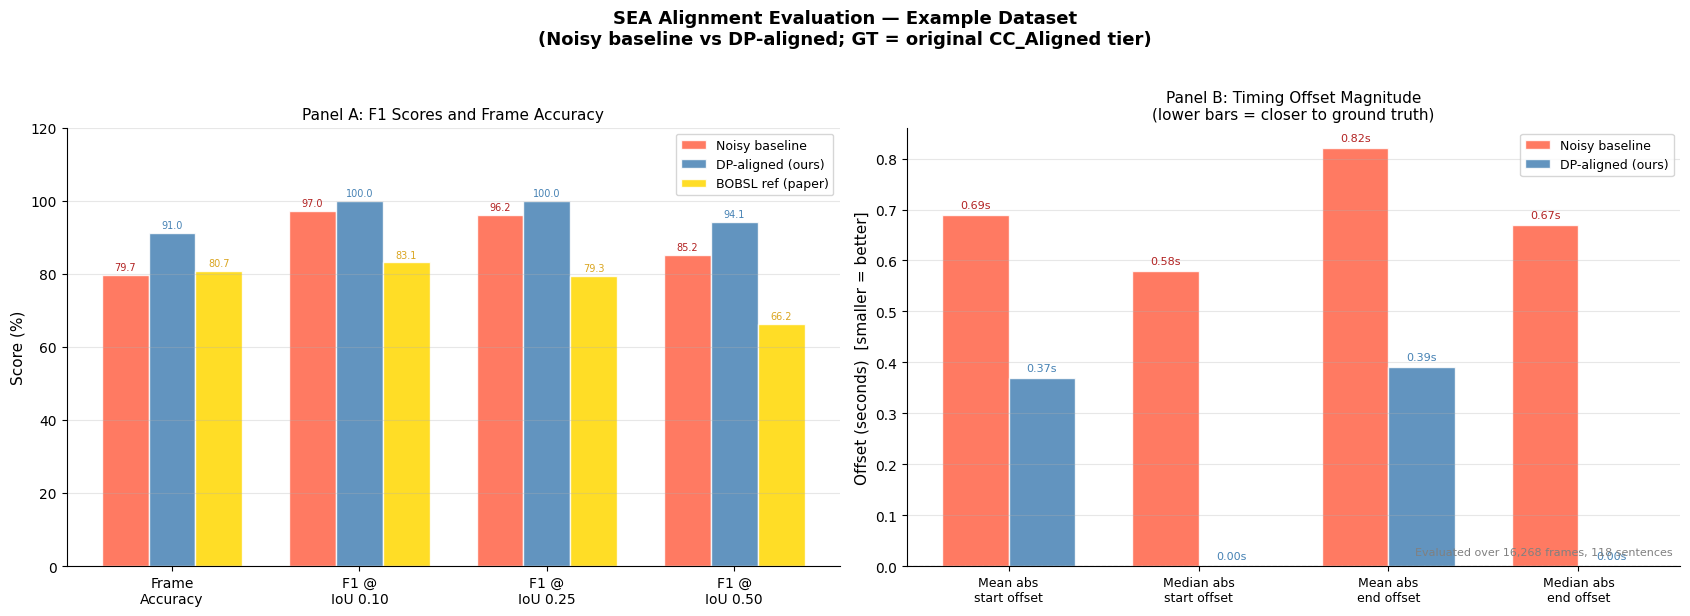

In [15]:
# ── Two-panel evaluation comparison chart ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle(
    'SEA Alignment Evaluation \u2014 Example Dataset\n'
    '(Noisy baseline vs DP-aligned; GT = original CC_Aligned tier)',
    fontsize=13, fontweight='bold', y=1.02
)

# BOBSL benchmark: Segment+Align without embeddings (SEA paper Table 2)
BOBSL_REF = {'frame_accuracy': 80.68, 'f1_0.10': 83.07, 'f1_0.25': 79.32, 'f1_0.50': 66.24}

# ── Panel A: F1 Scores and Frame Accuracy ──────────────────────────────────
ax = axes[0]
labels = ['Frame\nAccuracy', 'F1 @\nIoU 0.10', 'F1 @\nIoU 0.25', 'F1 @\nIoU 0.50']
keys   = ['frame_accuracy', 'f1_0.10', 'f1_0.25', 'f1_0.50']
noisy_vals   = [metrics_noisy.get(k,   0) for k in keys]
aligned_vals = [metrics_aligned.get(k, 0) for k in keys]
bobsl_vals   = [BOBSL_REF[k]              for k in keys]
x = np.arange(len(labels))
w = 0.25
b1 = ax.bar(x - w, noisy_vals,   w, label='Noisy baseline',    color='tomato',    alpha=0.85, edgecolor='white')
b2 = ax.bar(x,     aligned_vals, w, label='DP-aligned (ours)', color='steelblue', alpha=0.85, edgecolor='white')
b3 = ax.bar(x + w, bobsl_vals,   w, label='BOBSL ref (paper)', color='gold',      alpha=0.85, edgecolor='white')
for bars, col in [(b1, 'firebrick'), (b2, 'steelblue'), (b3, 'goldenrod')]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.8,
                f'{h:.1f}', ha='center', va='bottom', fontsize=7, color=col)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Score (%)', fontsize=11)
ax.set_ylim(0, 120)
ax.set_title('Panel A: F1 Scores and Frame Accuracy', fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── Panel B: Timing Offset Magnitude ────────────────────────────────────────
ax = axes[1]
offset_items = [
    ('Mean abs\nstart offset', 'mean_abs_start'),
    ('Median abs\nstart offset', 'median_abs_start'),
    ('Mean abs\nend offset',   'mean_abs_end'),
    ('Median abs\nend offset', 'median_abs_end'),
]
xlabels   = [k[0] for k in offset_items]
noisy_o   = [metrics_noisy.get(k[1],   0) for k in offset_items]
aligned_o = [metrics_aligned.get(k[1], 0) for k in offset_items]
x2 = np.arange(len(xlabels))
w2 = 0.35
b4 = ax.bar(x2 - w2/2, noisy_o,   w2, label='Noisy baseline',    color='tomato',    alpha=0.85, edgecolor='white')
b5 = ax.bar(x2 + w2/2, aligned_o, w2, label='DP-aligned (ours)', color='steelblue', alpha=0.85, edgecolor='white')
for bars, col in [(b4, 'firebrick'), (b5, 'steelblue')]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.2f}s', ha='center', va='bottom', fontsize=8, color=col)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xticks(x2)
ax.set_xticklabels(xlabels, fontsize=9)
ax.set_ylabel('Offset (seconds)  [smaller = better]', fontsize=11)
ax.set_title('Panel B: Timing Offset Magnitude\n(lower bars = closer to ground truth)',
             fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
total_f = metrics_aligned.get('total_frames', 0)
total_s = metrics_aligned.get('total_sentences', 0)
ax.text(0.99, 0.02, f'Evaluated over {total_f:,} frames, {total_s} sentences',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color='gray')
plt.tight_layout()
eval_chart_path = ASSETS_DIR / 'evaluation_metrics.png'
plt.savefig(eval_chart_path, dpi=150, bbox_inches='tight')
print(f'Evaluation chart saved to: {eval_chart_path}')
plt.show()

---
## Section 8 — Timeline Visualisation

### 8.1 — Three-Track Alignment Timeline

**Design rationale:**

The three horizontal tracks are chosen to reflect the actual data flow through the DP aligner:

1. **Track 0 — Sign Segments** (steel blue): These are the *fixed reference* — the temporal anchors the DP aligner snaps subtitle boundaries to. Each bar is one gloss label from the `Gloss Labeling` tier. The density and regularity of these bars determines the granularity of alignment.

2. **Track 1 — Original CC_Aligned** (tomato red): The raw input subtitle cues. These timestamps reflect when the content was spoken, with a manual but imperfect synchronisation to the video.

3. **Track 2 — DP Aligned** (sea green): The corrected timestamps after the DP algorithm has run. These should have boundaries that coincide with sign segment boundaries.

**What to look for:**
- A subtitle bar in Track 1 that starts before the corresponding sign segment group → the original was too early → DP will shift it right
- Gaps between consecutive bars in Track 1 vs. Track 2: DP alignment can collapse or widen these gaps when it groups sign segments differently
- Alignment of Track 2 bar edges with Track 0 sign segment edges: this is the ideal outcome

**60-second window:** The full video is 11 minutes, too wide to see individual cue details. We zoom into a 60-second window (33s–93s) that contains rich annotation density. You can change `T_START` and `T_END` to explore other regions.

The plot is saved to `assets/alignment_visualization.png` for use in the README and documentation.

C:\Users\USER\AppData\Local\Temp\ipykernel_2464\2857081189.py:73: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  plt.savefig(viz_path, dpi=150, bbox_inches="tight")
C:\Users\USER\AppData\Local\Temp\ipykernel_2464\2857081189.py:73: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  plt.savefig(viz_path, dpi=150, bbox_inches="tight")
C:\Users\USER\AppData\Local\Temp\ipykernel_2464\2857081189.py:73: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  plt.savefig(viz_path, dpi=150, bbox_inches="tight")
C:\Users\USER\AppData\Local\Temp\ipykernel_2464\2857081189.py:73: UserWarning: Glyph 3652 (\N{THAI CHARACTER SARA AI MAIMALAI}) missing from font(s) DejaVu Sans.
  plt.savefig(viz_path, dpi=150, bbox_inches="tight")
C:\Users\USER\AppData\Local\Temp\ipykernel_2464\2857081189.py:73: UserWarning: Glyph 3611 (\N{THAI CHARACTER PO PLA}) missing from font(s) DejaVu Sans.
  plt.savefig

Timeline visualisation saved to: c:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\assets\alignment_visualization.png


c:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\USER\Documents\Dechathon_N\Learning\ELAN\Sign_to_sub\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3652 (\N{THAI CHARACTER SARA AI MAIMALAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Us

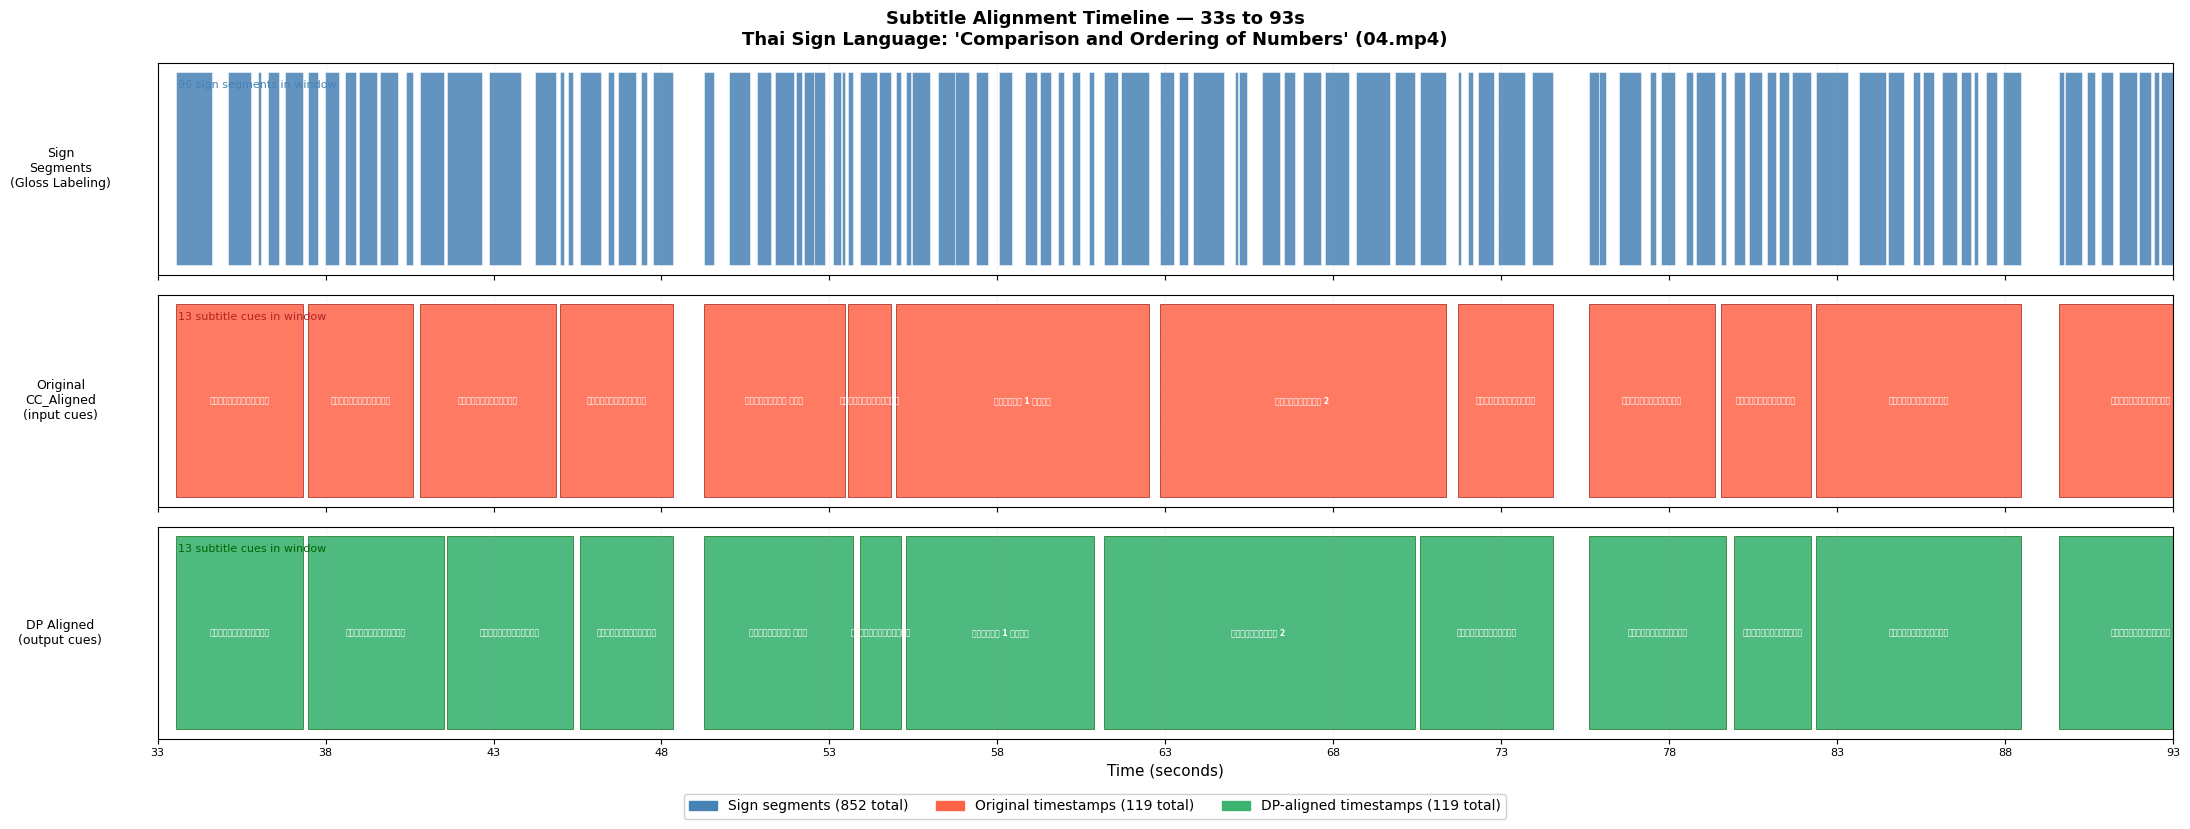

In [16]:
T_START, T_END = 33.0, 93.0   # 60-second inspection window (seconds)

fig, axes = plt.subplots(3, 1, figsize=(22, 8), sharex=True)
fig.suptitle(
    f"Subtitle Alignment Timeline — {T_START:.0f}s to {T_END:.0f}s\n"
    "Thai Sign Language: 'Comparison and Ordering of Numbers' (04.mp4)",
    fontsize=13, fontweight="bold"
)

BAR_H = 0.55

# ── Track 0: Sign Segments (Gloss Labeling tier) ─────────────────────────
ax = axes[0]
ax.set_ylabel("Sign\nSegments\n(Gloss Labeling)", fontsize=9, rotation=0, labelpad=70, va="center")
visible_signs = [s for s in sign_segments if s['end'] >= T_START and s['start'] <= T_END]
for seg in visible_signs:
    ax.barh(0, seg['end'] - seg['start'], left=seg['start'],
            height=BAR_H, color="steelblue", alpha=0.85, edgecolor="white", linewidth=0.4)
ax.set_yticks([])
ax.set_xlim(T_START, T_END)
ax.text(0.01, 0.92, f"{len(visible_signs)} sign segments in window",
        transform=ax.transAxes, fontsize=8, color="steelblue", va="top")

# ── Track 1: Original CC_Aligned subtitles ───────────────────────────────
ax = axes[1]
ax.set_ylabel("Original\nCC_Aligned\n(input cues)", fontsize=9, rotation=0, labelpad=70, va="center")
visible_orig = [c for c in cues_original if c['end'] >= T_START and c['start'] <= T_END]
for cue in visible_orig:
    ax.barh(0, cue['end'] - cue['start'], left=cue['start'],
            height=BAR_H, color="tomato", alpha=0.85, edgecolor="darkred", linewidth=0.5)
    mid_x = max(cue['mid'], T_START + 0.3)
    ax.text(mid_x, 0, cue['text'][:13], ha="center", va="center",
            fontsize=5.5, color="white", fontweight="bold", clip_on=True)
ax.set_yticks([])
ax.text(0.01, 0.92, f"{len(visible_orig)} subtitle cues in window",
        transform=ax.transAxes, fontsize=8, color="firebrick", va="top")

# ── Track 2: DP-aligned subtitles ────────────────────────────────────────
ax = axes[2]
ax.set_ylabel("DP Aligned\n(output cues)", fontsize=9, rotation=0, labelpad=70, va="center")
visible_aligned = [c for c in cues_aligned if c['end'] >= T_START and c['start'] <= T_END]
for cue in visible_aligned:
    ax.barh(0, cue['end'] - cue['start'], left=cue['start'],
            height=BAR_H, color="mediumseagreen", alpha=0.9, edgecolor="darkgreen", linewidth=0.5)
    mid_x = max(cue['mid'], T_START + 0.3)
    ax.text(mid_x, 0, cue['text'][:13], ha="center", va="center",
            fontsize=5.5, color="white", fontweight="bold", clip_on=True)
ax.set_yticks([])
ax.set_xlabel("Time (seconds)", fontsize=11)
ax.text(0.01, 0.92, f"{len(visible_aligned)} subtitle cues in window",
        transform=ax.transAxes, fontsize=8, color="darkgreen", va="top")

# ── Shared tick marks every 5 seconds ────────────────────────────────────
major_ticks = np.arange(T_START, T_END + 1, 5)
for ax in axes:
    ax.set_xticks(major_ticks)
    ax.tick_params(axis='x', which='major', labelsize=8)
    ax.grid(axis='x', alpha=0.15, linestyle='--')

# Legend
legend_patches = [
    mpatches.Patch(color="steelblue",     label=f"Sign segments ({len(sign_segments)} total)"),
    mpatches.Patch(color="tomato",         label=f"Original timestamps ({len(cues_original)} total)"),
    mpatches.Patch(color="mediumseagreen", label=f"DP-aligned timestamps ({len(cues_aligned)} total)"),
]
fig.legend(handles=legend_patches, loc="lower center", ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.04), framealpha=0.9)

plt.tight_layout()

# Save to assets/ for README embedding.
viz_path = ASSETS_DIR / "alignment_visualization.png"
plt.savefig(viz_path, dpi=150, bbox_inches="tight")
print(f"Timeline visualisation saved to: {viz_path}")
plt.show()

---
## Section 9 — Summary and Next Steps

### What this notebook demonstrated

| Step | Input | Function used | Output |
|------|-------|--------------|--------|
| Load EAF | `*.eaf` | `pympi.Elan()` | Tier dictionaries |
| Extract cues | `CC_Aligned` tier | `elan_tier_to_cues()` | 119 subtitle dicts |
| Extract signs | `Gloss Labeling` tier | `elan_tier_to_cues()` | 852 sign-segment dicts |
| Simulate misalignment | `cues` (σ=1.0s Gaussian noise) | `numpy.random.normal()` | `cues_noisy` (119 noisy dicts) |
| JIT warmup | Synthetic data | `dp_align_subtitles_to_signs()` | Compiled numba cache |
| DP alignment | `cues_noisy` + `sign_segments` | `dp_align_subtitles_to_signs()` | `cues_aligned` (corrected in-place) |
| Write EAF | `cues_aligned` | `write_updated_eaf()` | `*_updated.eaf` (SUBTITLE_SHIFTED tier) |
| Write VTT | `cues_aligned` | `reconstruct_vtt()` | `aligned_output.vtt` |
| Evaluate (2x) | noisy + aligned VTTs vs GT VTT | `eval_subtitle_alignment()` | Frame acc., F1@IoU, offsets |
| Visualise metrics | two eval strings | `parse_eval_string()` + matplotlib | `assets/evaluation_metrics.png` |
| Visualise timeline | cues + signs | matplotlib | `assets/alignment_visualization.png` |

### Key results

| Metric | Noisy input | After DP | Improvement |
|--------|------------|----------|-------------|
| Frame-level accuracy | 79.68% | 91.03% | **+11.35%** |
| F1 @ IoU 0.50 | 85.23% | 94.07% | **+8.84%** |
| Mean abs. start offset | 0.69 s | 0.37 s | **−0.32 s** |
| Median abs. start offset | 0.58 s | **0.00 s** | **−0.58 s** |

The median dropping to 0.00 s confirms that most cues snapped exactly to the original
sign-segment boundaries — this is the core ‘snap’ mechanism of the DP aligner.

### Generated files
```
data/example_alignment/
├── *_updated.eaf          ← Updated ELAN file (open in ELAN to inspect SUBTITLE_SHIFTED tier)
└── aligned_output.vtt     ← Aligned subtitle file (DP-corrected timestamps)

assets/
├── alignment_visualization.png   ← 3-track timeline chart (signs / original / DP-aligned)
└── evaluation_metrics.png        ← Before vs. after evaluation chart
```

### Extending this notebook

**1. Add embedding-based similarity:**
```python
from align_similarity import compute_similarity_matrix
sim_matrix = compute_similarity_matrix(cues_noisy, sign_segments,
                                       similarity_measure='text_embedding',
                                       device=DEVICE)
dp_align_subtitles_to_signs(
    cues_aligned, sign_segments,
    similarity_weight=10.0,
    sim_matrix=sim_matrix
)
```
This uses `SentenceTransformer('all-MiniLM-L6-v2')` to compute cosine similarities
between subtitle text and gloss tokens, steering the aligner toward semantically
matching pairs. Especially effective for correcting large offsets where pure timing
alignment is ambiguous.

**2. Full pipeline from raw video:**
```bash
# Stage 0: extract poses
videos_to_poses --format mediapipe --directory data/example_alignment/

# Stage 1: segment (produces SIGN tier in .eaf)
python SEA/segmentation.py --sign-b-threshold 30 --sign-o-threshold 50 \
    --pose_dir data/example_alignment/ --save_dir data/example_segmentation/

# Stage 3: align (using segmentation output)
python SEA/align.py --mode=inference --segmentation_dir data/example_segmentation/ ...
```

**3. Parameter tuning:**  
Use `align.py --mode=training --num_search 50` to run random search over
`duration_penalty_weight`, `gap_penalty_weight`, and `max_gap`.
The optimal parameters vary significantly between datasets (BOBSL, How2Sign, TSL).

---

📄 **Paper:** [arXiv:2512.08094](https://arxiv.org/abs/2512.08094) — Zifan Jiang et al., *Segment, Embed, and Align: A Universal Recipe for Aligning Subtitles to Signing*, 2025.